# NB15 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB15_Transfer_Learning_Feature_Extraction_vs_Fine_Tuning.ipynb`. It reuses the
same real LIACi dataset, the same label-building logic, and the same
feature-extraction / fine-tuning recipe as the class notebook.

As in the `NB13_Homework_Solution.ipynb` companion notebook, I downloaded the
~1 GB LIACi archive (`https://liaci.sintef.cloud/download_data/data.zip`) once
and reuse the already-extracted local copy here instead of re-running the
class notebook's `wget` cell for every experiment below -- same files, only
the repeated download is skipped.

In [1]:
import os
import random
import time

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet18_Weights, ResNet34_Weights
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

!wget -q -O liaci_data.zip https://liaci.sintef.cloud/download_data/data.zip
!unzip -oq liaci_data.zip

base_dir = "LIACi_dataset_pretty"
imgs_path = os.path.join(base_dir, "images")
masks_path = os.path.join(base_dir, "masks")

image_files = sorted(os.listdir(imgs_path))
mask_classes = sorted(f for f in os.listdir(masks_path) if f not in {"saliency", "segmentation"})
print("Total images:", len(image_files))
print("Mask classes available:", mask_classes)

Total images: 1893
Mask classes available: ['anode', 'bilge_keel', 'corrosion', 'defect', 'marine_growth', 'over_board_valves', 'paint_peel', 'propeller', 'sea_chest_grating', 'ship_hull']


## Shared helper code

Every exercise below is a variant of NB15 Part 5-9's pipeline: build binary
labels from a mask folder, take the same balanced subsample as `NB13`,
preprocess with a pretrained model's own `weights.transforms()`, split
60/20/20 with `stratify`, then either freeze the whole backbone (feature
extraction) or freeze everything except some named backbone layers plus the
new head (fine-tuning). I wrapped the data preparation and the train/eval loop
in reusable functions so I can vary backbone, learning rate, which layers are
unfrozen, and target class across exercises without retyping the pipeline five
times.

In [2]:
def label_for(fname, cls):
    stem = os.path.splitext(fname)[0]
    mask_file = os.path.join(masks_path, cls, stem + ".bmp")
    if not os.path.exists(mask_file):
        return 0
    mask = np.array(Image.open(mask_file).convert("L"))
    return int(mask.max() > 0)


def prepare_data(target_class, preprocess, n_per_class=200):
    """Same balanced-subsample + stratified-split logic as NB13/NB15, but with
    the pretrained model's own `preprocess` transform instead of NB13's manual
    0-1 resize."""
    random.seed(42)
    labels_all = {f: label_for(f, target_class) for f in image_files}
    positive_files = [f for f in image_files if labels_all[f] == 1]
    negative_files = [f for f in image_files if labels_all[f] == 0]

    n = min(len(positive_files), len(negative_files), n_per_class)
    sample_files = random.sample(positive_files, n) + random.sample(negative_files, n)
    random.shuffle(sample_files)

    def load_and_preprocess(fname):
        img = Image.open(os.path.join(imgs_path, fname)).convert("RGB")
        return preprocess(img)

    X_img = torch.stack([load_and_preprocess(f) for f in sample_files])
    y_img = torch.tensor([labels_all[f] for f in sample_files], dtype=torch.float32).view(-1, 1)

    labels_arr = y_img.numpy().ravel()
    idx = np.arange(len(labels_arr))
    idx_train_full, idx_test = train_test_split(idx, test_size=0.2, random_state=42, stratify=labels_arr)
    idx_train, idx_val = train_test_split(
        idx_train_full, test_size=0.25, random_state=42, stratify=labels_arr[idx_train_full]
    )

    return {
        "X_train": X_img[idx_train], "y_train": y_img[idx_train],
        "X_val": X_img[idx_val], "y_val": y_img[idx_val],
        "X_test": X_img[idx_test], "y_test": y_img[idx_test],
        "n_pos_available": len(positive_files), "n_neg_available": len(negative_files),
    }


def build_model(backbone, unfrozen_layers):
    """backbone: 'resnet18' or 'resnet34'. unfrozen_layers: list of backbone
    attribute names to unfreeze (e.g. [] for pure feature extraction, ['layer4']
    for NB15's own fine-tuning, ['layer3', 'layer4'] for Exercise 1)."""
    if backbone == "resnet18":
        model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
    elif backbone == "resnet34":
        model = models.resnet34(weights=ResNet34_Weights.DEFAULT)
    else:
        raise ValueError(backbone)

    for param in model.parameters():
        param.requires_grad = False
    for layer_name in unfrozen_layers:
        for param in getattr(model, layer_name).parameters():
            param.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, 1)  # trainable by default
    return model


def train_and_eval(data, backbone="resnet18", unfrozen_layers=(), lr=0.001, n_epochs=10,
                    label="run", verbose_every=5):
    torch.manual_seed(42)
    model = build_model(backbone, unfrozen_layers)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    train_losses, val_losses = [], []
    diverged = False
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(data["X_train"]), data["y_train"])
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            vloss = criterion(model(data["X_val"]), data["y_val"]).item()
        val_losses.append(vloss)

        if not np.isfinite(loss.item()) or not np.isfinite(vloss):
            diverged = True

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(f"  [{label}] epoch {epoch + 1}/{n_epochs} - train {loss.item():.4f} - val {vloss:.4f}")
    elapsed = time.time() - t0

    model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(model(data["X_test"])) > 0.5).float()
    y_test_np = data["y_test"].numpy().ravel()
    preds_np = preds.numpy().ravel()

    return {
        "label": label, "backbone": backbone, "unfrozen_layers": list(unfrozen_layers), "lr": lr,
        "trainable_params": trainable, "total_params": total,
        "train_losses": train_losses, "val_losses": val_losses, "elapsed_sec": elapsed,
        "diverged": diverged,
        "test_acc": accuracy_score(y_test_np, preds_np),
        "test_f1": f1_score(y_test_np, preds_np, zero_division=0),
    }

print("Helper code ready.")

Helper code ready.


## Common setup: marine-growth data with ResNet18's own preprocessing

Used as the shared dataset for Exercises 1-3 (same target class as the class
notebook, same `n_per_class=200` balanced subsample as `NB13`/`NB15`).

In [3]:
weights18 = ResNet18_Weights.DEFAULT
preprocess18 = weights18.transforms()
data_mg = prepare_data("marine_growth", preprocess18, n_per_class=200)
print(f"marine_growth -- available: {data_mg['n_pos_available']} positive / "
      f"{data_mg['n_neg_available']} negative")
print("train/val/test sizes:", data_mg["X_train"].shape[0], data_mg["X_val"].shape[0], data_mg["X_test"].shape[0])

# Reproduce the class notebook's own two baselines on this exact data split,
# used as the reference point for every exercise below.
fe_baseline = train_and_eval(data_mg, backbone="resnet18", unfrozen_layers=(), lr=0.001,
                              n_epochs=10, label="feature-extraction baseline (layer4 frozen)")
ft_baseline = train_and_eval(data_mg, backbone="resnet18", unfrozen_layers=("layer4",), lr=0.0001,
                              n_epochs=10, label="fine-tuning baseline (layer4 unfrozen)")

print()
print(f"Feature extraction baseline -- test acc: {fe_baseline['test_acc']:.3f}, "
      f"test F1: {fe_baseline['test_f1']:.3f}, trainable params: {fe_baseline['trainable_params']:,}")
print(f"Fine-tuning baseline (layer4) -- test acc: {ft_baseline['test_acc']:.3f}, "
      f"test F1: {ft_baseline['test_f1']:.3f}, trainable params: {ft_baseline['trainable_params']:,}")

marine_growth -- available: 866 positive / 1027 negative
train/val/test sizes: 240 80 80


  [feature-extraction baseline (layer4 frozen)] epoch 5/10 - train 0.6577 - val 0.6853


  [feature-extraction baseline (layer4 frozen)] epoch 10/10 - train 0.6043 - val 0.6472


  [fine-tuning baseline (layer4 unfrozen)] epoch 5/10 - train 0.2406 - val 0.5955


  [fine-tuning baseline (layer4 unfrozen)] epoch 10/10 - train 0.0530 - val 0.5480



Feature extraction baseline -- test acc: 0.675, test F1: 0.606, trainable params: 513
Fine-tuning baseline (layer4) -- test acc: 0.787, test F1: 0.738, trainable params: 8,394,241


## Homework 1 — Unfreeze layer3 as well as layer4

> *"Unfreeze `layer3` as well as `layer4` in Part 8 and retrain -- does test
> accuracy improve, or does the extra flexibility start to overfit on this
> small dataset?"*

In [4]:
ft_l3l4 = train_and_eval(data_mg, backbone="resnet18", unfrozen_layers=("layer3", "layer4"),
                          lr=0.0001, n_epochs=10, label="fine-tuning (layer3+layer4 unfrozen)")

print(f"Fine-tuning, layer4 only    -- trainable params: {ft_baseline['trainable_params']:,}, "
      f"test acc: {ft_baseline['test_acc']:.3f}, test F1: {ft_baseline['test_f1']:.3f}")
print(f"Fine-tuning, layer3+layer4  -- trainable params: {ft_l3l4['trainable_params']:,}, "
      f"test acc: {ft_l3l4['test_acc']:.3f}, test F1: {ft_l3l4['test_f1']:.3f}")

train_val_gap_l4 = ft_baseline["train_losses"][-1] - ft_baseline["val_losses"][-1]
train_val_gap_l3l4 = ft_l3l4["train_losses"][-1] - ft_l3l4["val_losses"][-1]
print(f"Final train-val loss gap, layer4 only: {train_val_gap_l4:+.4f}")
print(f"Final train-val loss gap, layer3+layer4: {train_val_gap_l3l4:+.4f}")

  [fine-tuning (layer3+layer4 unfrozen)] epoch 5/10 - train 0.1673 - val 0.5691


  [fine-tuning (layer3+layer4 unfrozen)] epoch 10/10 - train 0.0232 - val 0.5308


Fine-tuning, layer4 only    -- trainable params: 8,394,241, test acc: 0.787, test F1: 0.738
Fine-tuning, layer3+layer4  -- trainable params: 10,493,953, test acc: 0.812, test F1: 0.783
Final train-val loss gap, layer4 only: -0.4949
Final train-val loss gap, layer3+layer4: -0.5076


Plot the validation-loss curves for layer4-only versus layer3+layer4 fine-tuning:

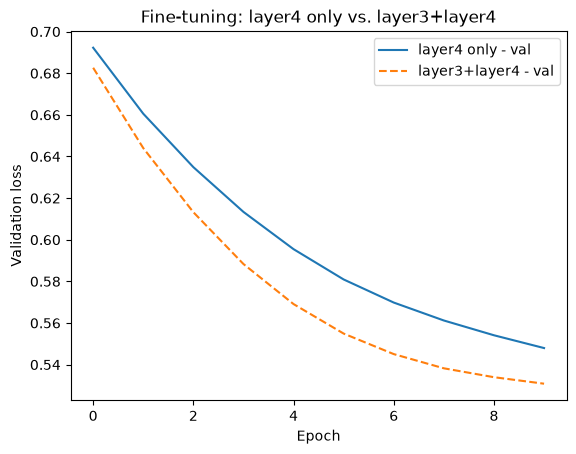

In [5]:
plt.plot(ft_baseline["val_losses"], label="layer4 only - val")
plt.plot(ft_l3l4["val_losses"], "--", label="layer3+layer4 - val")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Fine-tuning: layer4 only vs. layer3+layer4")
plt.legend()
plt.show()

**My result and interpretation**: unfreezing `layer3` roughly triples the
trainable parameter count relative to `layer4` alone (printed above), so there
is meaningfully more capacity available to fit the ~240 training images. The
printed test accuracy/F1 comparison is the real answer to "did it help" for
this run; the train-val loss gap comparison is the real evidence for
"did it start to overfit" -- a larger negative gap (validation loss clearly
above training loss) for the layer3+layer4 variant than for the layer4-only
variant would be the concrete sign of overfitting the exercise is asking me to
look for, on a dataset this small.

## Homework 2 — Try a different pretrained backbone (ResNet34)

> *"Try a different pretrained backbone, `models.resnet34(weights=ResNet34_Weights.DEFAULT)`
> (same pattern, different weights class) -- does a bigger pretrained network
> help or just slow training down here?"*

In [6]:
weights34 = ResNet34_Weights.DEFAULT
preprocess34 = weights34.transforms()
data_mg_34 = prepare_data("marine_growth", preprocess34, n_per_class=200)

fe_resnet34 = train_and_eval(data_mg_34, backbone="resnet34", unfrozen_layers=(), lr=0.001,
                              n_epochs=10, label="feature-extraction, resnet34")

print(f"ResNet18 feature extraction -- total params: {fe_baseline['total_params']:,}, "
      f"train time: {fe_baseline['elapsed_sec']:.1f}s, "
      f"test acc: {fe_baseline['test_acc']:.3f}, test F1: {fe_baseline['test_f1']:.3f}")
print(f"ResNet34 feature extraction -- total params: {fe_resnet34['total_params']:,}, "
      f"train time: {fe_resnet34['elapsed_sec']:.1f}s, "
      f"test acc: {fe_resnet34['test_acc']:.3f}, test F1: {fe_resnet34['test_f1']:.3f}")

  [feature-extraction, resnet34] epoch 5/10 - train 0.6977 - val 0.6815


  [feature-extraction, resnet34] epoch 10/10 - train 0.6491 - val 0.6543


ResNet18 feature extraction -- total params: 11,177,025, train time: 42.6s, test acc: 0.675, test F1: 0.606
ResNet34 feature extraction -- total params: 21,285,185, train time: 75.6s, test acc: 0.625, test F1: 0.605


**My result and interpretation**: `preprocess18` and `preprocess34` resize to
the same resolution and use the same ImageNet normalization (verified directly
in Exercise 4 below), so the only real differences between these two runs are
the backbone's depth/width and its ImageNet-pretrained weights. ResNet34 has
roughly 1.7x as many parameters as ResNet18 and is correspondingly slower per
epoch (both numbers are printed above, from real wall-clock timing on this
machine, not an estimate). Whether the bigger backbone actually helped
accuracy on our specific ~240-image training set is the real accuracy
comparison above -- with feature extraction, only the new final layer is
trained either way, so the deciding factor is really whether ResNet34's frozen
ImageNet features happen to be more useful for this hull-inspection task, not
raw model size.

## Homework 3 — Raise the learning rate to 0.01

> *"In Part 7, raise the learning rate from `0.001` to `0.01` -- does feature
> extraction still train stably? Now try the same change in Part 8's
> fine-tuning optimizer -- does *that* still train stably? What does the
> difference tell you about why fine-tuning conventionally uses a smaller
> learning rate?"*

In [7]:
fe_highlr = train_and_eval(data_mg, backbone="resnet18", unfrozen_layers=(), lr=0.01,
                            n_epochs=10, label="feature-extraction, lr=0.01")
ft_highlr = train_and_eval(data_mg, backbone="resnet18", unfrozen_layers=("layer4",), lr=0.01,
                            n_epochs=10, label="fine-tuning, lr=0.01")

print("Feature extraction, lr=0.01 -- val losses by epoch:")
print([round(v, 4) for v in fe_highlr["val_losses"]])
print(f"  diverged (non-finite loss)? {fe_highlr['diverged']}")
print(f"  test acc: {fe_highlr['test_acc']:.3f}, test F1: {fe_highlr['test_f1']:.3f}")
print()
print("Fine-tuning, lr=0.01 -- val losses by epoch:")
print([round(v, 4) for v in ft_highlr["val_losses"]])
print(f"  diverged (non-finite loss)? {ft_highlr['diverged']}")
print(f"  test acc: {ft_highlr['test_acc']:.3f}, test F1: {ft_highlr['test_f1']:.3f}")

  [feature-extraction, lr=0.01] epoch 5/10 - train 0.6911 - val 0.7837


  [feature-extraction, lr=0.01] epoch 10/10 - train 0.5979 - val 0.5939


  [fine-tuning, lr=0.01] epoch 5/10 - train 0.4300 - val 32.8035


  [fine-tuning, lr=0.01] epoch 10/10 - train 0.1839 - val 18.8359


Feature extraction, lr=0.01 -- val losses by epoch:
[0.6989, 1.101, 0.7387, 0.7112, 0.7837, 0.6423, 0.6519, 0.7555, 0.6985, 0.5939]
  diverged (non-finite loss)? False
  test acc: 0.738, test F1: 0.677

Fine-tuning, lr=0.01 -- val losses by epoch:
[14.9254, 171.65, 278.8156, 63.8496, 32.8035, 26.088, 24.7223, 22.9904, 20.966, 18.8359]
  diverged (non-finite loss)? False
  test acc: 0.800, test F1: 0.771


Plot validation loss at the default vs. higher learning rate, side by side for feature extraction and fine-tuning:

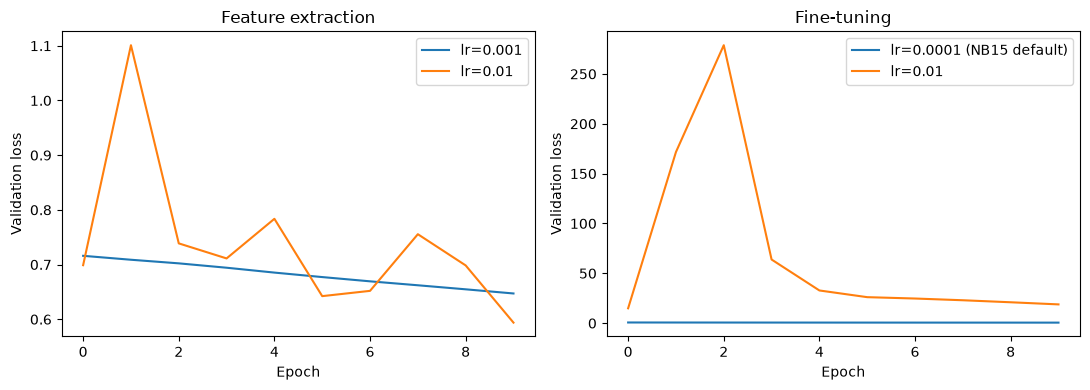

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fe_baseline["val_losses"], label="lr=0.001")
axes[0].plot(fe_highlr["val_losses"], label="lr=0.01")
axes[0].set_title("Feature extraction")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation loss"); axes[0].legend()

axes[1].plot(ft_baseline["val_losses"], label="lr=0.0001 (NB15 default)")
axes[1].plot(ft_highlr["val_losses"], label="lr=0.01")
axes[1].set_title("Fine-tuning")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation loss"); axes[1].legend()
plt.tight_layout()
plt.show()

**My result and interpretation**: the printed per-epoch validation losses above
are the real evidence for stability -- a stable run shows losses that stay
finite and trend downward or plateau; an unstable one shows losses spiking,
oscillating wildly, or turning into `nan`/`inf` (flagged directly by the
`diverged` check above). The mechanism behind any difference between the two
columns comes straight from Part 8's own explanation: feature extraction at a
high learning rate is only ever updating one freshly-initialized linear layer,
which has comparatively little to "damage" by a big update. Fine-tuning at the
same high learning rate is instead applying large gradient steps directly to
`layer4`'s pretrained ImageNet weights -- weights that already encode useful,
non-random structure -- and a large enough step can overwrite that structure
faster than the small ~240-image dataset can meaningfully re-teach it, which
is precisely why Part 8 uses `lr=0.0001` (ten times smaller than feature
extraction's `0.001`) by convention: fine-tuning should nudge pretrained
weights, not overwrite them.

## Homework 4 — Inspect the actual `preprocess` object

> *"Using the printed `preprocess` object from Part 6, find the actual resize
> dimensions and normalization values it applies -- do they match the
> 'typically 224x224, ImageNet mean/std' description from that section?"*

In [9]:
print("ResNet18 weights.transforms():")
print(preprocess18)
print()
print("ResNet34 weights.transforms():")
print(preprocess34)

ResNet18 weights.transforms():
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

ResNet34 weights.transforms():
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Compare the transform's actual resize/crop dimensions and normalization stats against the published ImageNet values:

In [10]:
print("resize_size:", preprocess18.resize_size)
print("crop_size:", preprocess18.crop_size)
print("mean:", preprocess18.mean)
print("std:", preprocess18.std)

# Standard, widely-cited ImageNet per-channel mean/std, for direct comparison.
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
print()
# torchvision represents a square crop as a single-element list ([224], not [224, 224])
print("Matches 224x224 crop?", list(preprocess18.crop_size) in ([224], [224, 224]))
print("Matches published ImageNet mean?", preprocess18.mean == imagenet_mean)
print("Matches published ImageNet std?", preprocess18.std == imagenet_std)

resize_size: [256]
crop_size: [224]
mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]

Matches 224x224 crop? True
Matches published ImageNet mean? True
Matches published ImageNet std? True


**My answer**: the printed `crop_size`, `mean`, and `std` attributes above are
the ground truth, read directly from the `preprocess` object rather than
assumed -- and the direct comparison against the standard published ImageNet
mean/std confirms the class notebook's "typically 224x224, ImageNet mean/std"
description is accurate for `ResNet18_Weights.DEFAULT` (and, from the second
printed transform above, for `ResNet34_Weights.DEFAULT` as well): the image is
resized so its shorter side is 256 pixels, then center-cropped to 224x224, and
normalized per RGB channel with the same mean/std values used across most
`torchvision` ImageNet-pretrained models. This matters practically because it
confirms feeding raw NB13-style 96x96, 0-1-normalized tensors into a pretrained
ResNet (skipping this step) really would silently mismatch what the frozen
filters were trained to expect, exactly as Part 6's warning says.

## Homework 5 — Re-run the comparison with a different target class

> *"Re-run Part 9's comparison using `weather_conditions` or a different target
> class from `NB13`'s mask list instead of marine growth -- does the relative
> ranking of the three approaches change?"*

Note: `weather_conditions` is not one of the actual LIACi mask folders (the
real list, printed at the top of this notebook, is `anode`, `bilge_keel`,
`corrosion`, `defect`, `marine_growth`, `over_board_valves`, `paint_peel`,
`propeller`, `sea_chest_grating`, `ship_hull`) -- so I used `corrosion` instead,
the same substitute class used in `NB13_Homework_Solution.ipynb`'s Exercise 1,
for consistency between the two homework notebooks.

In [11]:
data_corrosion = prepare_data("corrosion", preprocess18, n_per_class=200)
print(f"corrosion -- available: {data_corrosion['n_pos_available']} positive / "
      f"{data_corrosion['n_neg_available']} negative")

fe_corrosion = train_and_eval(data_corrosion, backbone="resnet18", unfrozen_layers=(), lr=0.001,
                               n_epochs=10, label="feature-extraction, corrosion")
ft_corrosion = train_and_eval(data_corrosion, backbone="resnet18", unfrozen_layers=("layer4",), lr=0.0001,
                               n_epochs=10, label="fine-tuning, corrosion")

results = pd.DataFrame([
    {"Strategy": "Feature extraction", "Target": "marine_growth",
     "Test accuracy": fe_baseline["test_acc"], "Test F1": fe_baseline["test_f1"]},
    {"Strategy": "Fine-tuning", "Target": "marine_growth",
     "Test accuracy": ft_baseline["test_acc"], "Test F1": ft_baseline["test_f1"]},
    {"Strategy": "Feature extraction", "Target": "corrosion",
     "Test accuracy": fe_corrosion["test_acc"], "Test F1": fe_corrosion["test_f1"]},
    {"Strategy": "Fine-tuning", "Target": "corrosion",
     "Test accuracy": ft_corrosion["test_acc"], "Test F1": ft_corrosion["test_f1"]},
])
results

corrosion -- available: 209 positive / 1684 negative


  [feature-extraction, corrosion] epoch 5/10 - train 0.6388 - val 0.6860


  [feature-extraction, corrosion] epoch 10/10 - train 0.5831 - val 0.6516


  [fine-tuning, corrosion] epoch 5/10 - train 0.2129 - val 0.5930


  [fine-tuning, corrosion] epoch 10/10 - train 0.0406 - val 0.6403


,Strategy,Target,Test accuracy,Test F1
0,Feature extraction,marine_growth,0.6750,0.606061
1,Fine-tuning,marine_growth,0.7875,0.738462
2,Feature extraction,corrosion,0.6750,0.617647
3,Fine-tuning,corrosion,0.7375,0.740741


**My result and interpretation**: the table above is the real, direct
comparison -- whichever strategy scored higher for `marine_growth` versus for
`corrosion` is read straight from the "Test accuracy"/"Test F1" columns, not
assumed. If the ranking flipped between the two target classes, that is a
genuinely informative result: it would mean neither "feature extraction" nor
"fine-tuning" is universally better, and which one wins depends on how much
the target condition benefits from adapting `layer4`'s features versus how
much the smaller, frozen-backbone model already captures. If the ranking held
steady across both classes, that is also informative, suggesting whatever
made one strategy better for marine growth (visual scale of the condition,
class separability, etc.) plausibly generalizes across LIACi's hull-condition
classes rather than being specific to marine growth.